#📦 Capstone Project: Delivery Cost Prediction Using Machine Learning

| **Column Name**         | **Description**                                          | **Data Type**    | **Example**  |
| ----------------------- | -------------------------------------------------------- | ---------------- | ------------ |
| **delivery_id**         | Unique identifier for each delivery record.              | String / Integer | `D12345`     |
| **delivery_partner**    | Name or ID of the delivery personnel/partner.            | String           | `Partner_07` |
| **package_type**        | Category/type of the package being delivered.            | String           | `Fragile`    |
| **vehicle_type**        | Type of vehicle used for delivery.                       | String           | `Bike`       |
| **delivery_mode**       | Mode of delivery (e.g., express, standard).              | String           | `Express`    |
| **region**              | Geographic region of the delivery.                       | String           | `North Zone` |
| **weather_condition**   | Weather during delivery time.                            | String           | `Rainy`      |
| **distance_km**         | Distance to be covered for delivery (in kilometers).     | Float            | `12.5`       |
| **package_weight_kg**   | Weight of the package in kilograms.                      | Float            | `3.2`        |
| **delivery_time_hours** | Actual delivery time taken in hours.                     | Float            | `1.8`        |
| **expected_time_hours** | Expected delivery time in hours.                         | Float            | `1.5`        |
| **delayed**             | Indicates if the delivery was delayed (0 = No, 1 = Yes). | Integer (Binary) | `1`          |
| **delivery_status**     | Final status of delivery (e.g., delivered, canceled).    | String           | `Delivered`  |
| **delivery_rating**     | Customer rating for the delivery service (scale 1–5).    | Integer / Float  | `4`          |
| **delivery_cost**       | Total cost charged for the delivery.                     | Float            | `299.0`      |


In [ ]:
path='/content/Delivery_Logistics.csv'

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')
sns.set_palette('Set2')
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PowerTransformer,StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
df = pd.read_csv(path)
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [ ]:
df.shape

(25000, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


In [ ]:
df['delivery_id'].nunique()

24502

In [ ]:
df['delivery_time_hours'].unique()

array(['1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000002',
       '1970-01-01 00:00:00.000000010', '1970-01-01 00:00:00.000000006',
       '1970-01-01 00:00:00.000000009', '1970-01-01 00:00:00.000000004',
       '1970-01-01 00:00:00.000000005', '1970-01-01 00:00:00.000000003',
       '1970-01-01 00:00:00.000000012', '1970-01-01 00:00:00.000000011',
       '1970-01-01 00:00:00.000000007', '1970-01-01 00:00:00.000000013',
       '1970-01-01 00:00:00.000000000', '1970-01-01 00:00:00.000000001',
       '1970-01-01 00:00:00.000000014', '1970-01-01 00:00:00.000000016',
       '1970-01-01 00:00:00.000000015', '1970-01-01 00:00:00.000000017',
       '1970-01-01 00:00:00.000000018', '1970-01-01 00:00:00.000000019'],
      dtype=object)

In [ ]:
df['expected_time_hours'].unique()

array(['1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000003',
       '1970-01-01 00:00:00.000000016', '1970-01-01 00:00:00.000000002',
       '1970-01-01 00:00:00.000000006', '1970-01-01 00:00:00.000000024',
       '1970-01-01 00:00:00.000000007', '1970-01-01 00:00:00.000000004',
       '1970-01-01 00:00:00.000000005'], dtype=object)

In [ ]:
cols_to_drop = ['delivery_id','delivery_time_hours','expected_time_hours']

df.drop(cols_to_drop,axis=1,inplace=True)

In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   delivery_partner   25000 non-null  object 
 1   package_type       25000 non-null  object 
 2   vehicle_type       25000 non-null  object 
 3   delivery_mode      25000 non-null  object 
 4   region             25000 non-null  object 
 5   weather_condition  25000 non-null  object 
 6   distance_km        25000 non-null  float64
 7   package_weight_kg  25000 non-null  float64
 8   delayed            25000 non-null  object 
 9   delivery_status    25000 non-null  object 
 10  delivery_rating    25000 non-null  int64  
 11  delivery_cost      25000 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 2.3+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600


#Exploratory Data Analysis (EDA)

#Univariate EDA

In [ ]:
num_cols = df.select_dtypes('number').columns.tolist()
num_cols

['distance_km', 'package_weight_kg', 'delivery_rating', 'delivery_cost']

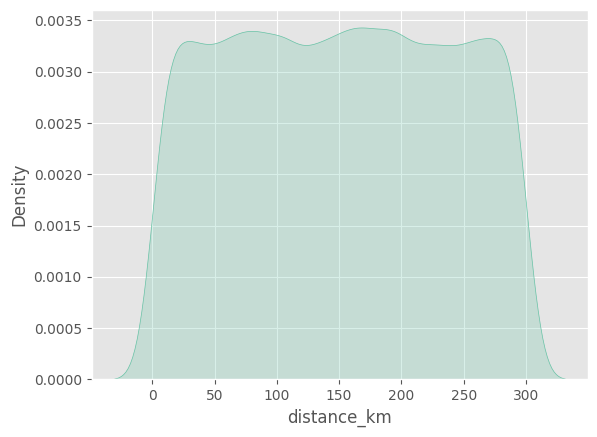

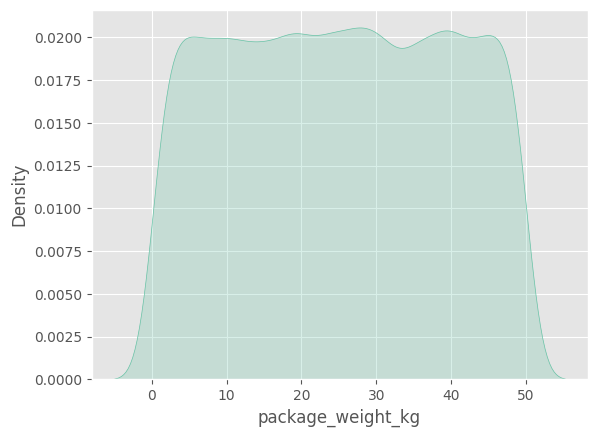

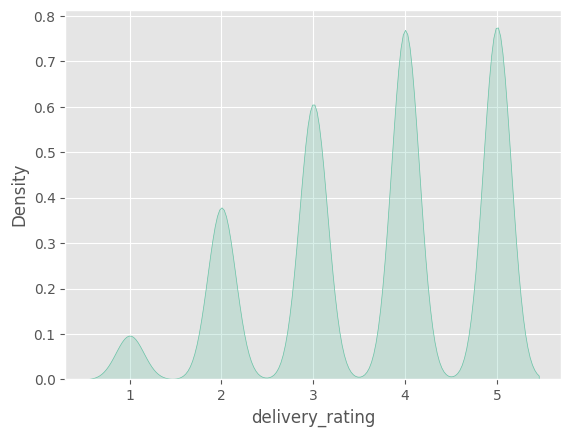

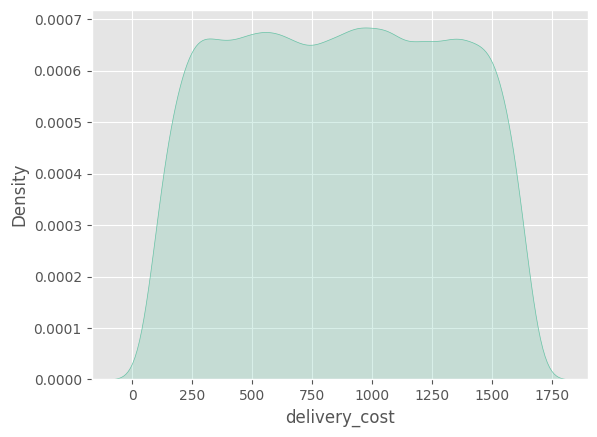

In [ ]:
for col in num_cols:
  sns.kdeplot(df[col],fill=True)
  plt.show()

In [ ]:
#lets apply transformation
df[num_cols].skew()

,0
distance_km,0.001883
package_weight_kg,-0.002607
delivery_rating,-0.473126
delivery_cost,0.001108


In [ ]:
df[num_cols].kurtosis()

,0
distance_km,-1.196196
package_weight_kg,-1.199496
delivery_rating,-0.738847
delivery_cost,-1.172019


In [ ]:
num_cols.remove('delivery_rating')

In [ ]:
num_cols

['distance_km', 'package_weight_kg', 'delivery_cost']

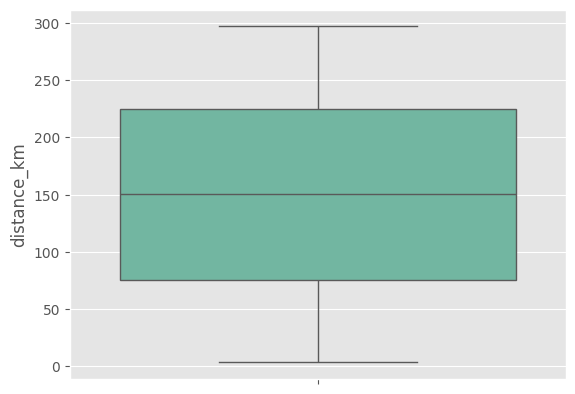

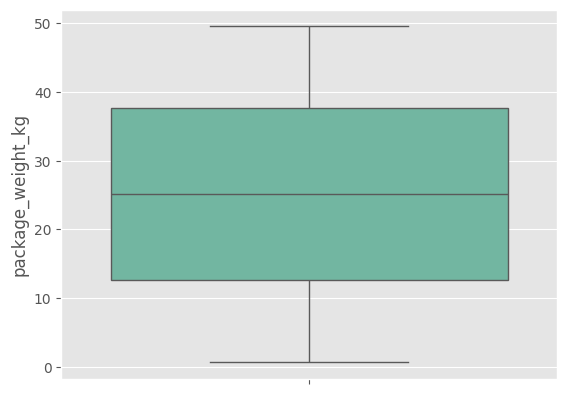

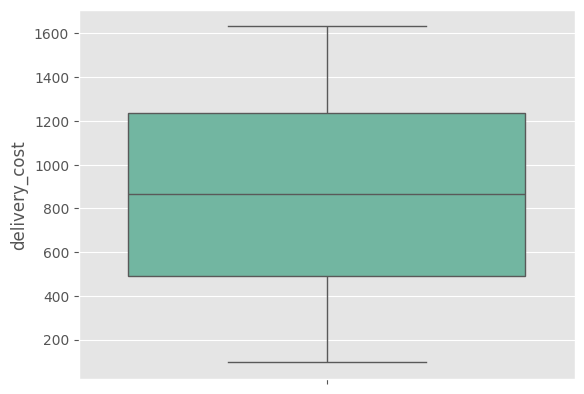

In [ ]:
for col in num_cols:
  sns.boxplot(df[col])
  plt.show()

In [ ]:
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols = cat_cols+['delivery_rating']
cat_cols

['delivery_partner',
 'package_type',
 'vehicle_type',
 'delivery_mode',
 'region',
 'weather_condition',
 'delayed',
 'delivery_status',
 'delivery_rating']

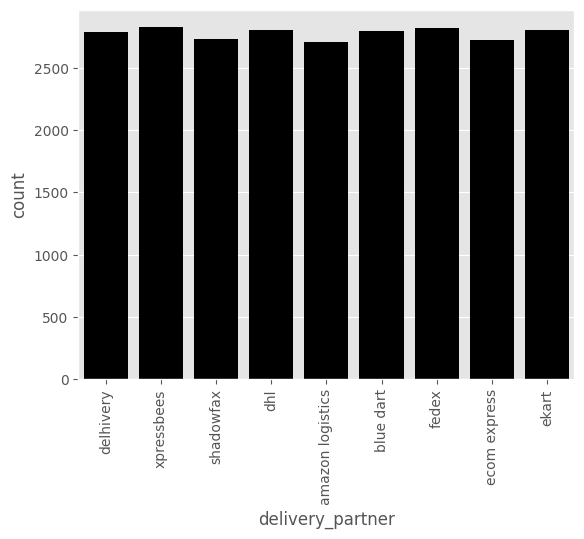

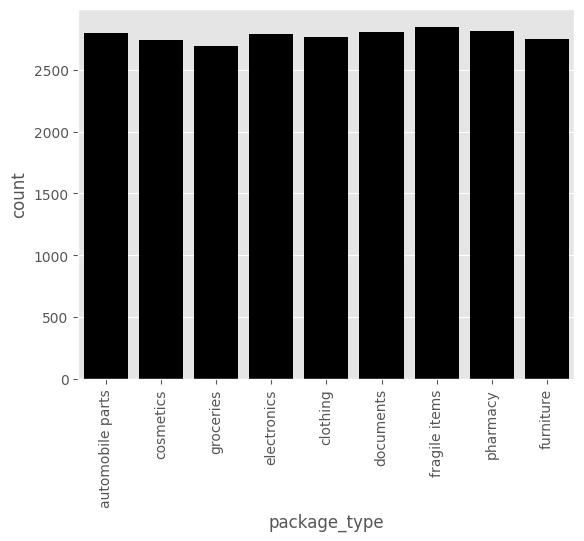

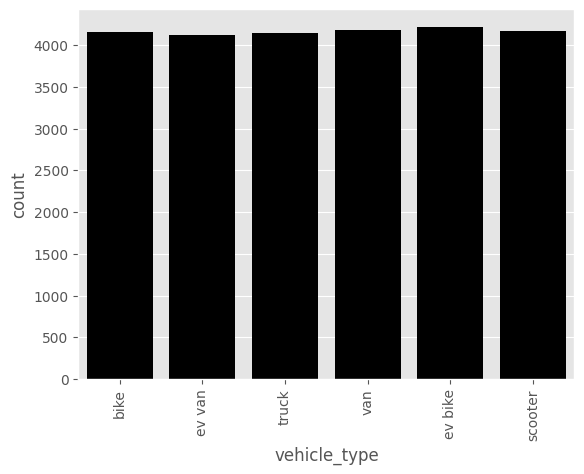

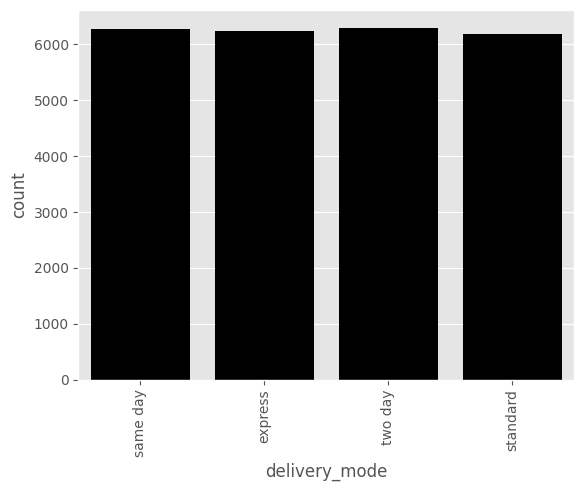

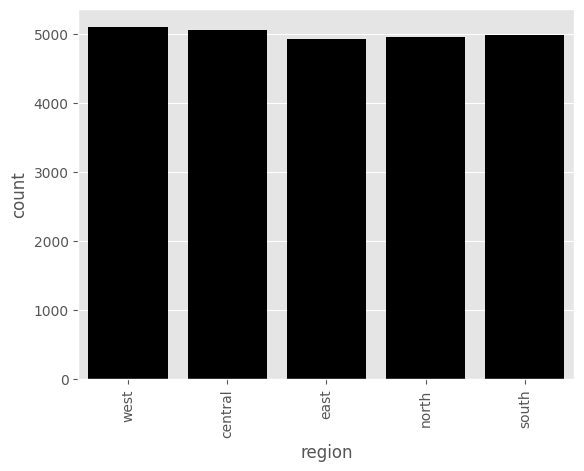

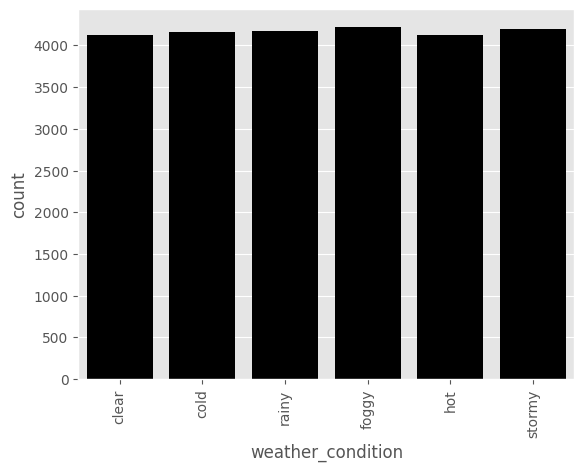

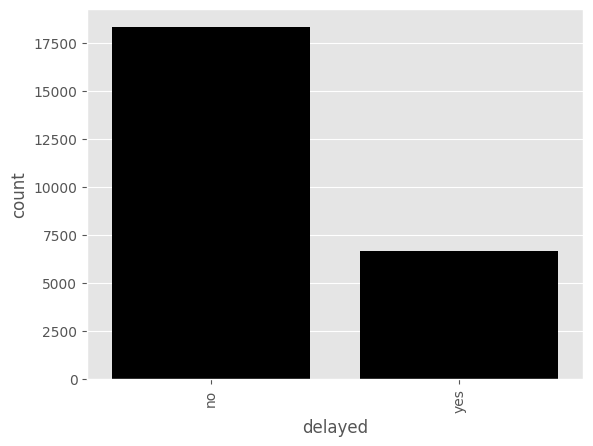

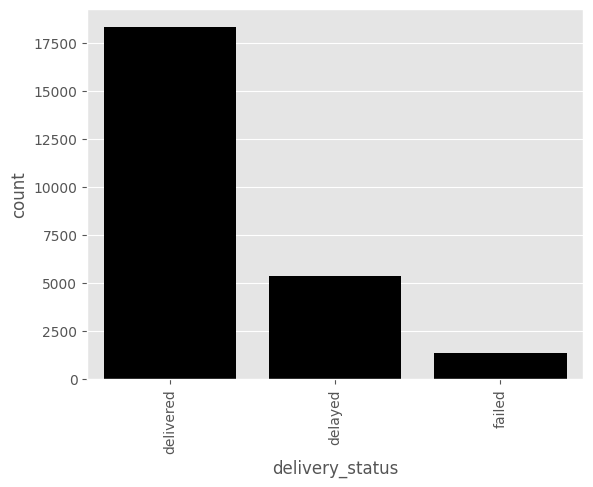

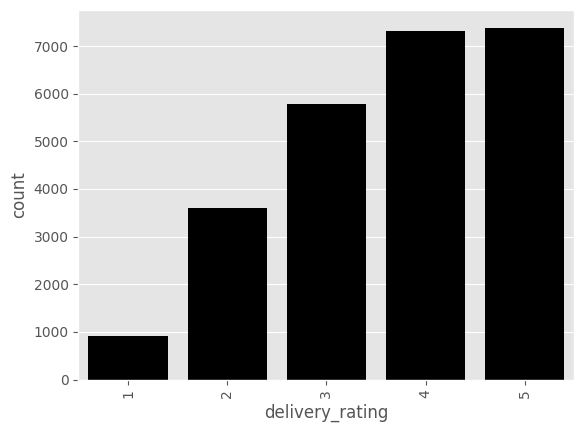

In [ ]:
for col in cat_cols:
  sns.countplot(data=df,x = col,color='k')
  plt.xticks(rotation=90)
  plt.show()

#Bivariate EDA

##Delivery cost vs distance

In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600


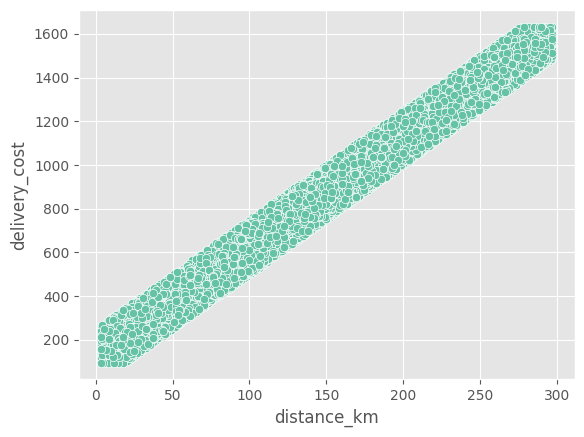

In [ ]:
sns.scatterplot(data=df,x = 'distance_km',y = 'delivery_cost')
plt.show()

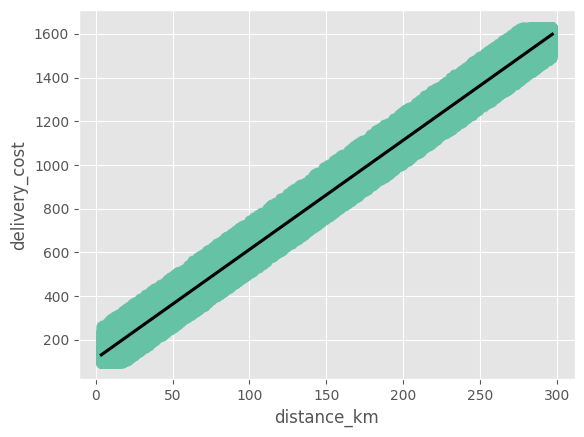

In [ ]:
sns.regplot(data=df,x = 'distance_km',y = 'delivery_cost',line_kws = {'color':'k'})
plt.show()

##Delivery cost vs vehicle_type

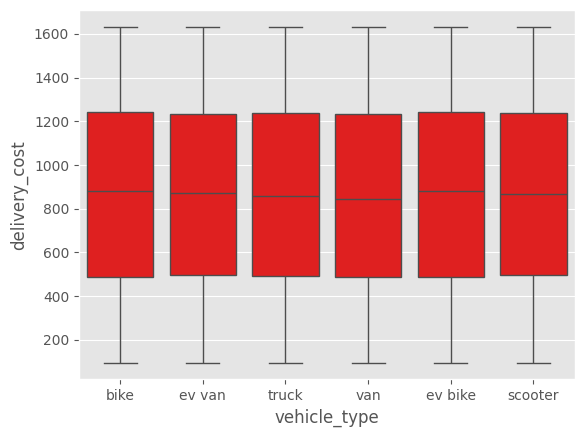

In [ ]:
sns.boxplot(data=df,x = 'vehicle_type',y='delivery_cost',color='r')
plt.show()

##Delivery cost vs weather

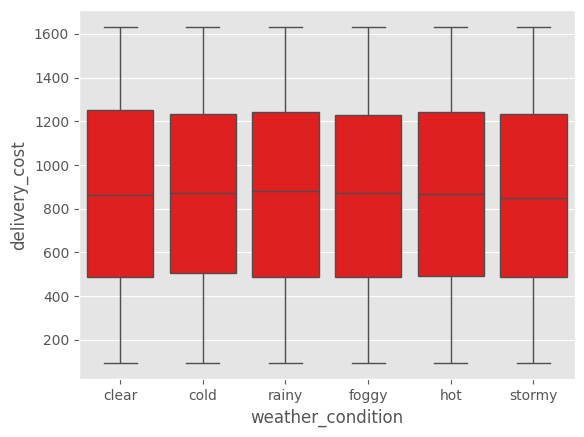

In [ ]:
sns.boxplot(data=df,x = 'weather_condition',y='delivery_cost',color='r')
plt.show()

##Delivery cost vs package_weight

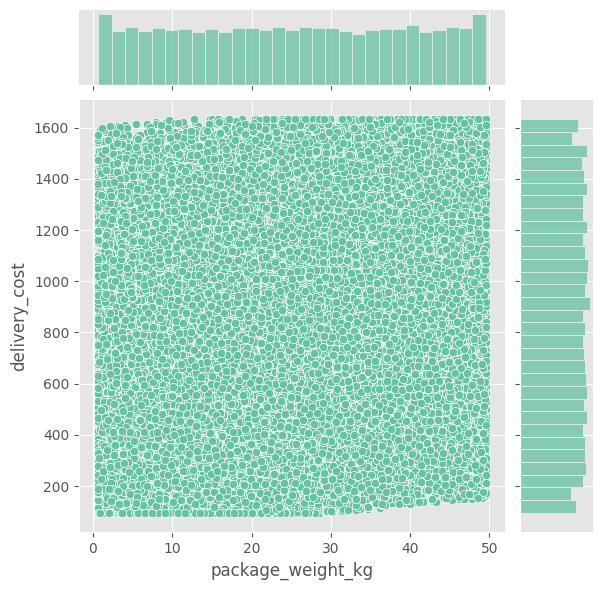

In [ ]:
sns.jointplot(data=df,x = 'package_weight_kg',y='delivery_cost')
plt.show()

#Multivariate EDA

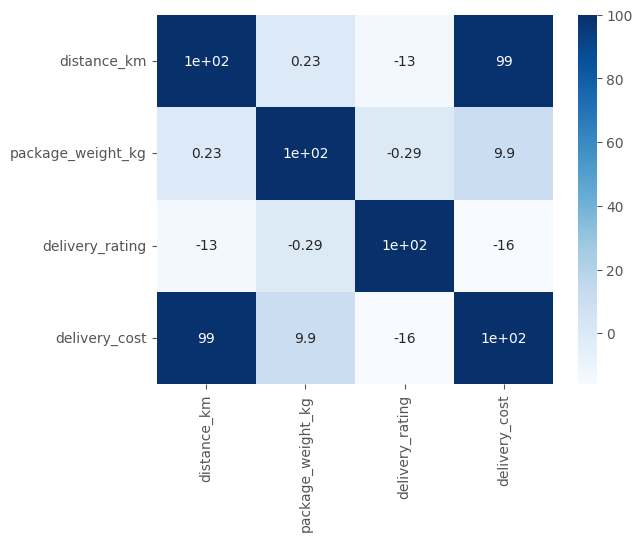

In [ ]:
sns.heatmap(df.corr(numeric_only=True)*100,annot=True,cmap='Blues')
plt.show()

In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600


In [ ]:
cat_cols

['delivery_partner',
 'package_type',
 'vehicle_type',
 'delivery_mode',
 'region',
 'weather_condition',
 'delayed',
 'delivery_status',
 'delivery_rating']

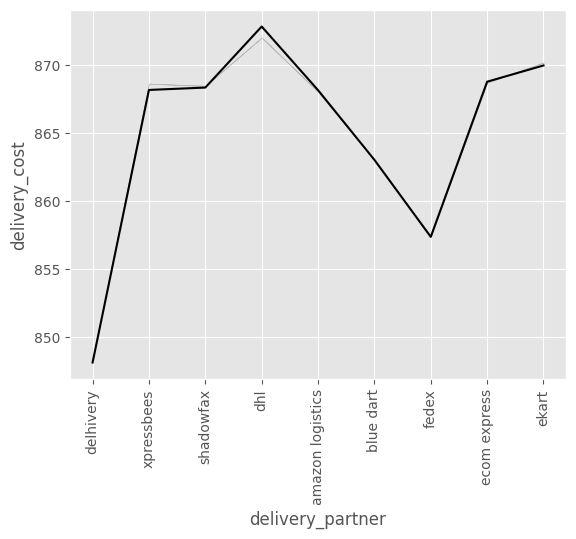

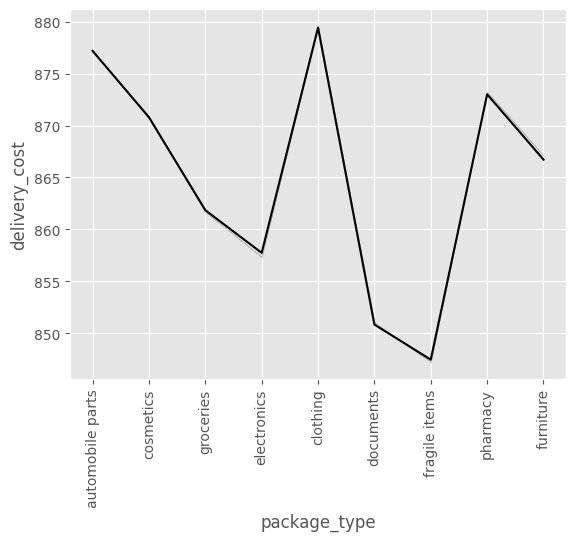

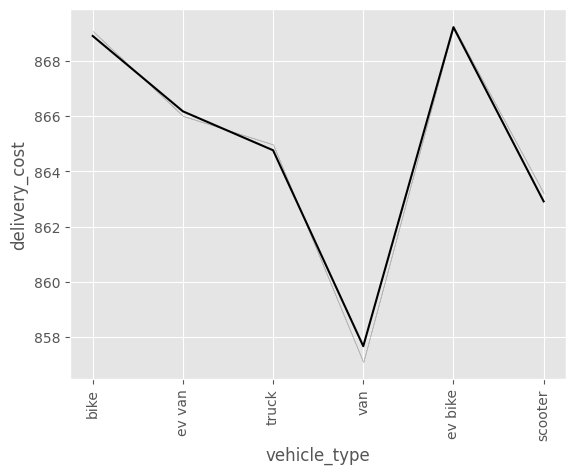

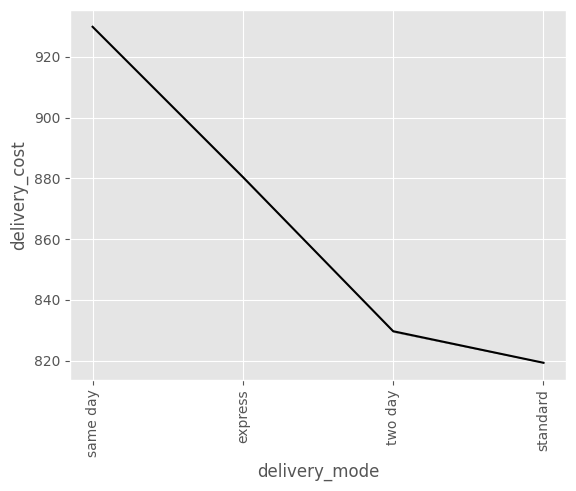

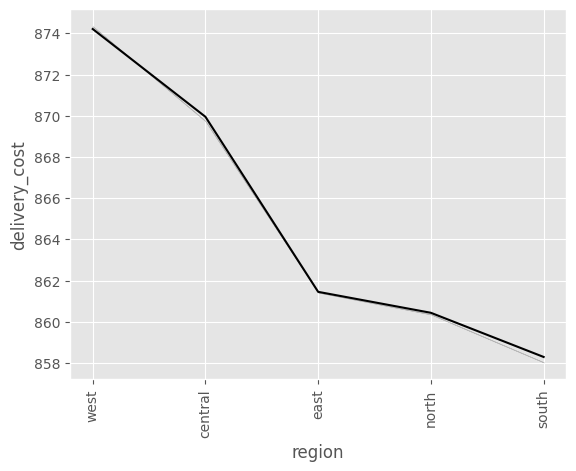

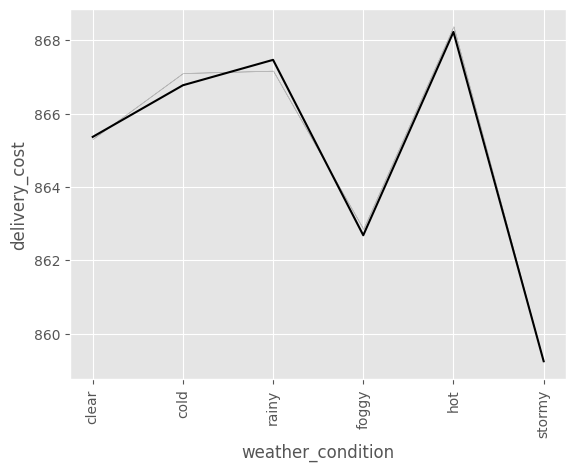

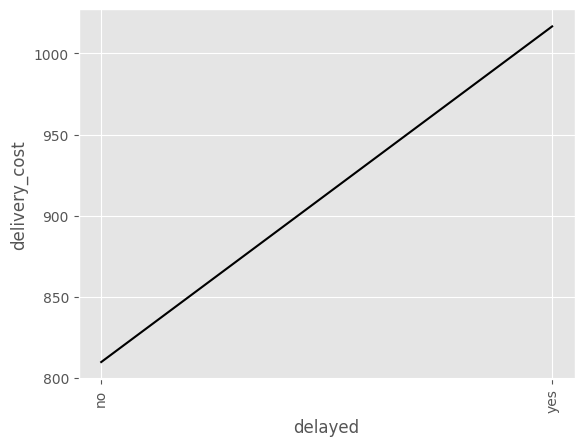

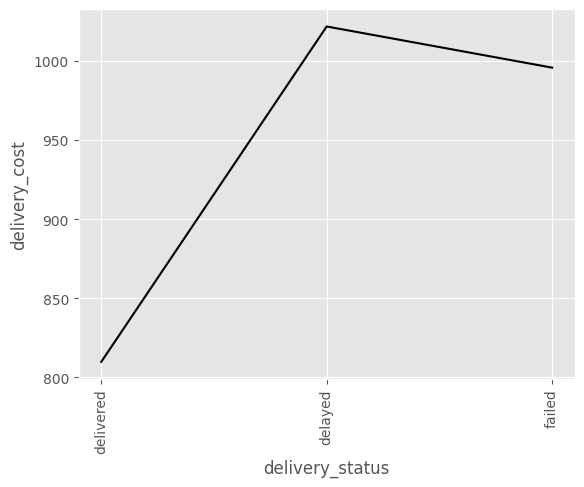

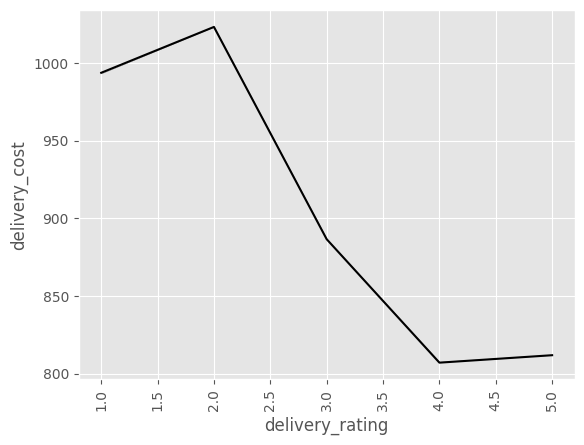

In [ ]:
target = 'delivery_cost'

for col in cat_cols:
  sns.lineplot(data=df,x = col,y=target,ci=False,color='k')
  plt.xticks(rotation=90)
  plt.show()

In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600


In [ ]:
# compare categorical columns with the target column : numerical

binary_cols = []

for col in cat_cols:
  if len(df[col].unique())==2:
    binary_cols.append(col)

binary_cols

['delayed']

In [ ]:
mcv_cols = []

for col in cat_cols:
  if len(df[col].unique())>2:
    mcv_cols.append(col)

mcv_cols

['delivery_partner',
 'package_type',
 'vehicle_type',
 'delivery_mode',
 'region',
 'weather_condition',
 'delivery_status',
 'delivery_rating']

In [ ]:
df['delayed'] = df['delayed'].map({'yes':1,'no':0})

In [ ]:
#for the binary vs numerical analysis we can use point biserial correlation test


#H0:no impact
#H1:significant impact

from scipy.stats import pointbiserialr as pb
pb(df['delayed'],df['delivery_cost'])

#looking at the p value we can say that there is a significant impact of delayed on delivery cost

SignificanceResult(statistic=np.float64(0.21001225650878047), pvalue=np.float64(3.361144134343574e-247))

In [ ]:
mcv_cols

['delivery_partner',
 'package_type',
 'vehicle_type',
 'delivery_mode',
 'region',
 'weather_condition',
 'delivery_status',
 'delivery_rating']

In [ ]:
from scipy.stats import f_oneway  #anova test [category vs numerical ]
df['delivery_partner'].unique()

array(['delhivery', 'xpressbees', 'shadowfax', 'dhl', 'amazon logistics',
       'blue dart', 'fedex', 'ecom express', 'ekart'], dtype=object)

In [ ]:
data = []
for level in df['delivery_partner'].unique():
  data.append(df[df['delivery_partner']==level]['delivery_cost'].tolist())

len(data)

9

In [ ]:
#H0:no impact
#H1:significant impact

f_oneway(*data) #"*" using star is unpacking to a list

F_onewayResult(statistic=np.float64(0.879462499385442), pvalue=np.float64(0.5328015415625067))

In [ ]:
for col in mcv_cols:
  data = []
  for level in df[col].unique():
    data.append(df[df[col]==level]['delivery_cost'].tolist())
  p = f_oneway(*data)[1]
  #print(f'p value for {col} vs delivery cost is {p}')
  if p<0.05:
    print(f'{col} has significant impact on delivery cost')
  else:
    print(f'{col} has no impact on delivery cost')

delivery_partner has no impact on delivery cost
package_type has no impact on delivery cost
vehicle_type has no impact on delivery cost
delivery_mode has significant impact on delivery cost
region has no impact on delivery cost
weather_condition has no impact on delivery cost
delivery_status has significant impact on delivery cost
delivery_rating has significant impact on delivery cost


In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,0,delivered,3,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,0,delivered,5,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,0,delivered,4,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,0,delivered,3,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,0,delivered,4,1394.5600


In [ ]:
df['weather_condition'].unique()

array(['clear', 'cold', 'rainy', 'foggy', 'hot', 'stormy'], dtype=object)

In [ ]:
df.columns

Index(['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
       'region', 'weather_condition', 'distance_km', 'package_weight_kg',
       'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost'],
      dtype='object')

In [ ]:

df['weight_per_km'] = df['package_weight_kg'] / df['distance_km']
df['bad_weather_flag'] = df['weather_condition'].isin(['rainy','stormy','foggy']).astype(int)
df['priority_flag'] = (df['delivery_mode'] == 'express').astype(int)
df['priority_distance_interaction'] = df['priority_flag'] * df['distance_km']

df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,weight_per_km,bad_weather_flag,priority_flag,priority_distance_interaction
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,0,delivered,3,1632.7206,0.158114,0,0,0.0
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,0,delivered,5,640.1700,0.528906,0,1,89.6
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,0,delivered,4,1448.1700,0.098318,1,0,0.0
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,0,delivered,3,1486.5700,0.047052,0,0,0.0
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,0,delivered,4,1394.5600,0.144215,1,0,0.0


In [ ]:
df.columns

Index(['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
       'region', 'weather_condition', 'distance_km', 'package_weight_kg',
       'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost',
       'weight_per_km', 'bad_weather_flag', 'priority_flag',
       'priority_distance_interaction'],
      dtype='object')

In [ ]:
df = df[['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
       'region', 'weather_condition', 'distance_km', 'package_weight_kg',
       'delayed', 'delivery_status', 'delivery_rating',
       'weight_per_km', 'bad_weather_flag', 'priority_flag',
       'priority_distance_interaction','delivery_cost']]

df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,weight_per_km,bad_weather_flag,priority_flag,priority_distance_interaction,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,0,delivered,3,0.158114,0,0,0.0,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,0,delivered,5,0.528906,0,1,89.6,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,0,delivered,4,0.098318,1,0,0.0,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,0,delivered,3,0.047052,0,0,0.0,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,0,delivered,4,0.144215,1,0,0.0,1394.5600


In [ ]:
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols

['delivery_partner',
 'package_type',
 'vehicle_type',
 'delivery_mode',
 'region',
 'weather_condition',
 'delivery_status']

In [ ]:
for col in cat_cols:
  print(col,df[col].unique())

delivery_partner ['delhivery' 'xpressbees' 'shadowfax' 'dhl' 'amazon logistics' 'blue dart'
 'fedex' 'ecom express' 'ekart']
package_type ['automobile parts' 'cosmetics' 'groceries' 'electronics' 'clothing'
 'documents' 'fragile items' 'pharmacy' 'furniture']
vehicle_type ['bike' 'ev van' 'truck' 'van' 'ev bike' 'scooter']
delivery_mode ['same day' 'express' 'two day' 'standard']
region ['west' 'central' 'east' 'north' 'south']
weather_condition ['clear' 'cold' 'rainy' 'foggy' 'hot' 'stormy']
delivery_status ['delivered' 'delayed' 'failed']


In [ ]:
# delivery_partner mapping
partner_map = {
    'amazon logistics': 1,
    'delhivery': 2,
    'xpressbees': 3,
    'shadowfax': 4,
    'blue dart': 5,
    'ekart': 6,
    'ecom express': 7,
    'fedex': 8,
    'dhl': 9
}

# package_type mapping
package_map = {
    'documents': 1,
    'cosmetics': 2,
    'clothing': 3,
    'pharmacy': 4,
    'groceries': 5,
    'electronics': 6,
    'automobile parts': 7,
    'fragile items': 8,
    'furniture': 9
}

# vehicle_type mapping
vehicle_map = {
    'bike': 1,
    'scooter': 2,
    'ev bike': 3,
    'van': 4,
    'ev van': 5,
    'truck': 6
}

# delivery_mode mapping
mode_map = {
    'same day': 1,
    'express': 2,
    'two day': 3,
    'standard': 4
}


# region mapping
region_map = {
    'north': 1,
    'south': 2,
    'east': 3,
    'west': 4,
    'central': 5
}

# weather_condition mapping
weather_map = {
    'clear': 1,
    'hot': 2,
    'cold': 3,
    'rainy': 4,
    'foggy': 5,
    'stormy': 6
}

# delivery_status mapping
status_map = {
    'delivered': 1,
    'delayed': 2,
    'failed': 3
}

df['delivery_partner'] = df['delivery_partner'].map(partner_map)
df['package_type'] = df['package_type'].map(package_map)
df['vehicle_type'] = df['vehicle_type'].map(vehicle_map)
df['delivery_mode'] = df['delivery_mode'].map(mode_map)
df['region'] = df['region'].map(region_map)
df['weather_condition'] = df['weather_condition'].map(weather_map)
df['delivery_status'] = df['delivery_status'].map(status_map)


In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,weight_per_km,bad_weather_flag,priority_flag,priority_distance_interaction,delivery_cost
0,2,7,1,1,4,1,297.0,46.96,0,1,3,0.158114,0,0,0.0,1632.7206
1,3,2,5,2,5,3,89.6,47.39,0,1,5,0.528906,0,1,89.6,640.1700
2,4,5,6,3,3,4,273.5,26.89,0,1,4,0.098318,1,0,0.0,1448.1700
3,9,6,5,1,3,3,269.7,12.69,0,1,3,0.047052,0,0,0.0,1486.5700
4,9,3,4,3,1,5,256.7,37.02,0,1,4,0.144215,1,0,0.0,1394.5600


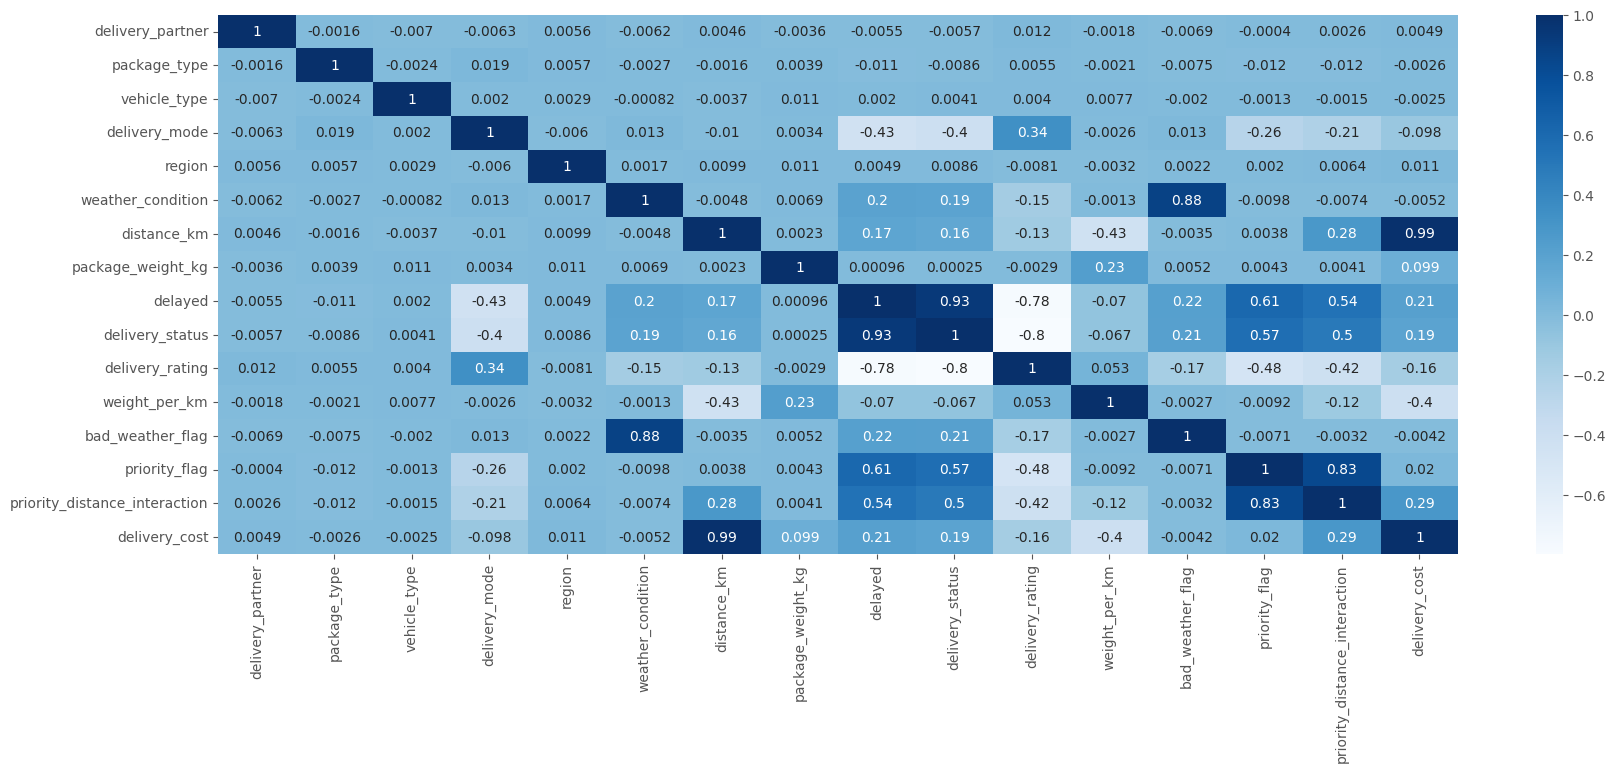

In [ ]:
plt.figure(figsize=(20,7))
sns.heatmap(df.corr(),annot=True,cmap='Blues')
plt.show()

In [ ]:
df.head()

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,weight_per_km,bad_weather_flag,priority_flag,priority_distance_interaction,delivery_cost
0,2,7,1,1,4,1,297.0,46.96,0,1,3,0.158114,0,0,0.0,1632.7206
1,3,2,5,2,5,3,89.6,47.39,0,1,5,0.528906,0,1,89.6,640.1700
2,4,5,6,3,3,4,273.5,26.89,0,1,4,0.098318,1,0,0.0,1448.1700
3,9,6,5,1,3,3,269.7,12.69,0,1,3,0.047052,0,0,0.0,1486.5700
4,9,3,4,3,1,5,256.7,37.02,0,1,4,0.144215,1,0,0.0,1394.5600


In [ ]:
df['bad_weather_flag'].unique()

array([0, 1])

In [ ]:
df['priority_flag'].unique()

array([0, 1])

In [ ]:
df['priority_distance_interaction'].unique()

array([  0. ,  89.6,  48.4, ..., 228.1, 258.4, 254.9])

#modelling

In [ ]:
x = df.drop(['delivery_cost'],axis=1)
y = df['delivery_cost']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(20000, 15)

In [ ]:
x_test.shape

(5000, 15)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train.mean(axis=0)

array([-1.03739239e-16,  1.19371180e-16, -8.52651283e-17,  1.27542421e-16,
       -1.24700250e-16,  8.31335001e-17, -2.81019652e-16, -2.63788991e-16,
        6.64357458e-17, -8.15347789e-17, -1.28608235e-16,  1.95399252e-17,
       -1.49213975e-17,  7.58504370e-17,  3.97903932e-17])

In [ ]:
x_train.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
linear = LinearRegression()
dt = DecisionTreeRegressor()
knn = KNeighborsRegressor()
rf = RandomForestRegressor()
xgb = XGBRegressor()

models = [linear,dt,knn,rf,xgb]
models

[LinearRegression(),
 DecisionTreeRegressor(),
 KNeighborsRegressor(),
 RandomForestRegressor(),
 XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)]

In [ ]:
scores = []


for model in models:
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  mae = mean_absolute_error(y_test,y_pred)
  mape =mean_absolute_percentage_error(y_test,y_pred)
  r2 = r2_score(y_test,y_pred)
  scores.append((model.__class__.__name__,mae,mape,r2))

In [ ]:
scores

[('LinearRegression',
  11.349600704152564,
  0.022294159569502526,
  0.9989789383123757),
 ('DecisionTreeRegressor', 5.54264768, 0.00934872667476834, 0.999713582894367),
 ('KNeighborsRegressor', 74.098494088, 0.1347972549553304, 0.9515606944483196),
 ('RandomForestRegressor',
  2.3226895008000032,
  0.00405344745237727,
  0.9999451183049268),
 ('XGBRegressor', 4.091255611975098, 0.007358928252812038, 0.9998510061269351)]

| Model                 | MAE     | MAPE    | R²      |
| --------------------- | ------- | ------- | ------- |
| LinearRegression      | 11.3496 | 0.02229 | 0.99898 |
| DecisionTreeRegressor | 5.5866  | 0.00930 | 0.99971 |
| KNeighborsRegressor   | 74.0985 | 0.13480 | 0.95156 |
| RandomForestRegressor | 2.3267  | 0.00411 | 0.99994 |
| XGBRegressor          | 4.0913  | 0.00736 | 0.99985 |


📌 Observations

RandomForestRegressor performs best with highest R² & lowest MAE/MAPE.

KNN performs poorly — likely due to scale sensitivity or suboptimal neighbors.

Linear Regression performs fairly well, suggesting linear structure exists.

XGBoost also performs strong but slightly behind Random Forest.

In [ ]:
model = RandomForestRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test,y_pred)
mape =mean_absolute_percentage_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [ ]:
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")
print(f"R-squared (R²): {r2:.6f}")

Mean Absolute Error (MAE): 2.2999
Mean Absolute Percentage Error (MAPE): 0.0040
R-squared (R²): 0.999946


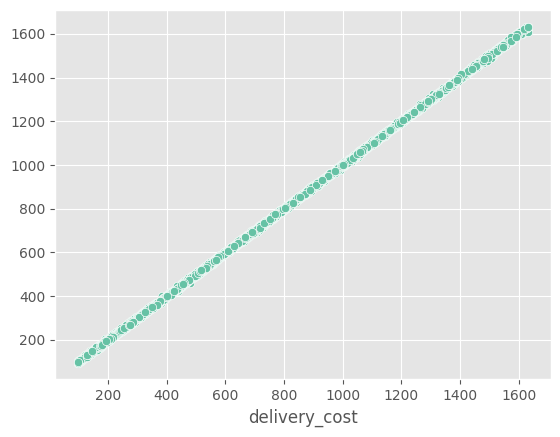

In [ ]:
sns.scatterplot(x = y_test,y = y_pred)
plt.show()

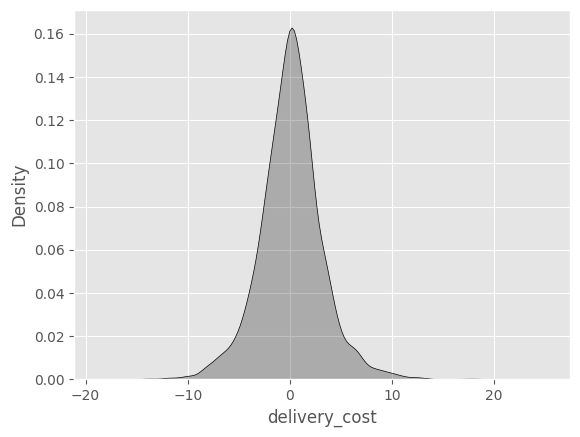

In [ ]:
residuals = y_test-y_pred
sns.kdeplot(residuals,fill=True,color='k')
plt.show()

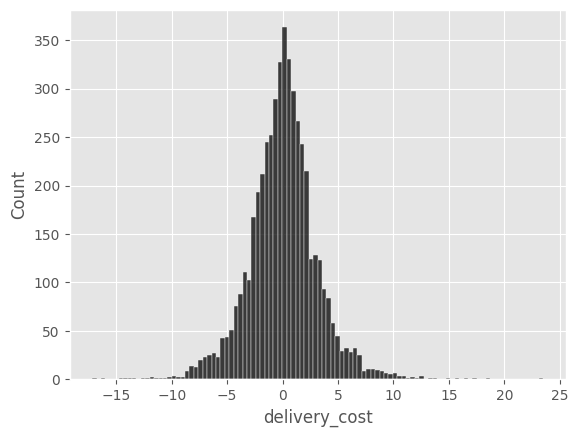

In [ ]:
sns.histplot(residuals,fill=True,color='k')
plt.show()

In [ ]:
x.columns

Index(['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
       'region', 'weather_condition', 'distance_km', 'package_weight_kg',
       'delayed', 'delivery_status', 'delivery_rating', 'weight_per_km',
       'bad_weather_flag', 'priority_flag', 'priority_distance_interaction'],
      dtype='object')

In [ ]:
model.feature_importances_

array([1.45440099e-05, 1.42048264e-05, 1.13905356e-05, 7.22788088e-03,
       1.03496192e-05, 9.86730189e-06, 9.81942112e-01, 9.07375420e-03,
       2.34382157e-06, 2.98767046e-06, 7.56921312e-06, 3.30744829e-04,
       2.33322845e-06, 3.64390690e-04, 9.85527113e-04])

In [ ]:
model_stats = pd.DataFrame(zip(x.columns,model.feature_importances_),columns = ['Features','Importances'])
model_stats.sort_values(by = 'Importances',ascending=False)


,Features,Importances
6,distance_km,0.981942
7,package_weight_kg,0.009074
3,delivery_mode,0.007228
14,priority_distance_interaction,0.000986
13,priority_flag,0.000364
11,weight_per_km,0.000331
0,delivery_partner,0.000015
1,package_type,0.000014
2,vehicle_type,0.000011
4,region,0.000010


In [ ]:
top5features = model_stats.sort_values(by = 'Importances',ascending=False).head(5)['Features'].tolist()
top5features

['distance_km',
 'package_weight_kg',
 'delivery_mode',
 'priority_distance_interaction',
 'priority_flag']

In [ ]:
x = df[top5features]
y = df['delivery_cost']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

final_model = RandomForestRegressor()
final_model.fit(x_train,y_train)

y_pred = final_model.predict(x_test)
mae = mean_absolute_error(y_test,y_pred)
mape =mean_absolute_percentage_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")
print(f"R-squared (R²): {r2:.6f}")

Mean Absolute Error (MAE): 1.7716
Mean Absolute Percentage Error (MAPE): 0.0031
R-squared (R²): 0.999967


- selecting the top 5 features reduces the mae by atleast 1 point showcasing that the selected features are the best for predicting the delivery cost

In [ ]:
mode_map = {
    'same day': 1,
    'express': 2,
    'two day': 3,
    'standard': 4
}

final_dataset = df[top5features+['delivery_cost']]
final_dataset

,distance_km,package_weight_kg,delivery_mode,priority_distance_interaction,priority_flag,delivery_cost
0,297.0,46.96,1,0.0,0,1632.7206
1,89.6,47.39,2,89.6,1,640.1700
2,273.5,26.89,3,0.0,0,1448.1700
3,269.7,12.69,1,0.0,0,1486.5700
4,256.7,37.02,3,0.0,0,1394.5600
...,...,...,...,...,...,...
24995,80.7,3.65,3,0.0,0,414.4500
24996,172.9,21.42,4,0.0,0,928.7600
24997,168.4,4.85,1,0.0,0,956.5500
24998,37.2,8.04,4,0.0,0,210.1200


In [ ]:
final_dataset.to_excel('final_data.xlsx',index=False)

#Save the final model using Pickle

In [ ]:
import pickle
with open('model.pkl','wb') as f:
  pickle.dump(final_model,f)

In [ ]:
with open('/content/model.pkl','rb') as f:
  loaded_model = pickle.load(f)


In [ ]:
loaded_model

RandomForestRegressor()

In [ ]:
final_dataset.sample(1)

,distance_km,package_weight_kg,delivery_mode,priority_distance_interaction,priority_flag,delivery_cost
23567,178.5,38.77,2,178.5,1,1058.81


In [ ]:
test = [[178.5	,38.77	,2	,178.5	,1]]
test = scaler.transform(test)

loaded_model.predict(test)

array([1059.6208])

#Deployment

In [ ]:
mode_map = {
    'same day': 1,
    'express': 2,
    'two day': 3,
    'standard': 4
}


distance = float(input('Enter Distance in Km'))
weight = float(input('Enter Weight in Km'))
mode =  int(input('Enter the Mode'))
flag = int(input('Enter Priority'))
priority_distance_interaction = distance*flag

test = [[distance,weight,mode,priority_distance_interaction,flag]]
test = scaler.transform(test)

cost = loaded_model.predict(test)

print('The Estimated Delivery Cost for the package would be ',cost,'$')

Enter Distance in Km200
Enter Weight in Km100
Enter the Mode1
Enter Priority1
The Estimated Delivery Cost for the package would be  [1218.5392] $
